In [1]:
#  Write a Python program to implement K-means clustering model and classify the 
# employees into various income groups or clusters. Preprocess data if require (i.e. drop 
# missing or null values). Use elbow method and Silhouette Score to find value of k. 

In [ ]:
import pandas as pd 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [15]:
data = pd.read_csv("D:/Machin Learning/ML/ML Preactical Slips/dataset/income.csv")
data


,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

In [25]:
scaler.fit(data[['Income($)']])

MinMaxScaler()

In [22]:
data['Income($)']=scaler.transform(data[['Income($)']])

In [26]:
scaler.fit(data[['Age']])

MinMaxScaler()

In [28]:
data['Age']=scaler.transform(data[['Age']])
data

,Name,Age,Income($)
0,Rob,-1.525952,0.213675
1,Michael,-1.519031,0.384615
2,Mohan,-1.519031,0.136752
3,Ismail,-1.522491,0.128205
4,Kory,-1.474048,0.897436
5,Gautam,-1.484429,0.940171
6,David,-1.477509,0.982906
7,Andrea,-1.487889,1.000000
8,Brad,-1.494810,0.948718
9,Angelina,-1.498270,0.726496


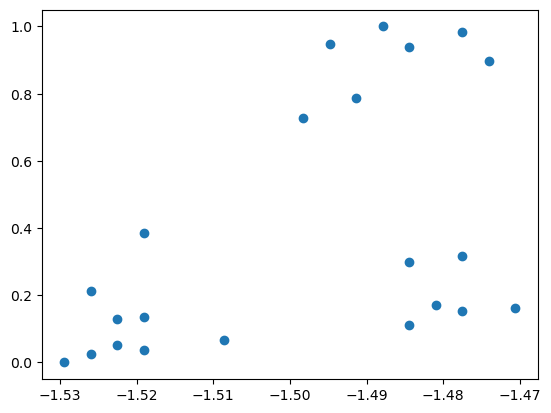

In [29]:
plt.scatter(data.Age,data['Income($)'])

In [31]:
Km = KMeans(n_clusters=3)

In [33]:
yp = Km.fit_predict(data[['Age' , 'Income($)']])
yp

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2])

In [34]:
data['cluster'] = yp
data

,Name,Age,Income($),cluster
0,Rob,-1.525952,0.213675,2
1,Michael,-1.519031,0.384615,0
2,Mohan,-1.519031,0.136752,2
3,Ismail,-1.522491,0.128205,2
4,Kory,-1.474048,0.897436,1
5,Gautam,-1.484429,0.940171,1
6,David,-1.477509,0.982906,1
7,Andrea,-1.487889,1.000000,1
8,Brad,-1.494810,0.948718,1
9,Angelina,-1.498270,0.726496,1


In [35]:
Km.cluster_centers_


array([[-1.49365629,  0.33333333],
       [-1.48690064,  0.8974359 ],
       [-1.50720877,  0.10505698]])

In [36]:
data1=data[data.cluster == 0]
data2 = data[data.cluster == 1]
data = data[data.cluster == 2]

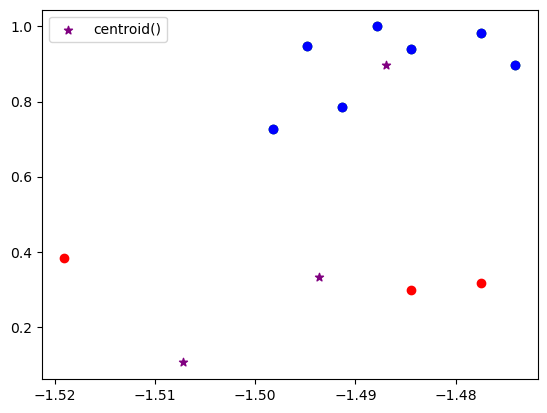

In [39]:
plt.scatter(data1.Age,data1['Income($)'],color="red")
plt.scatter(data2.Age,data2['Income($)'],color="green") 
plt.scatter(data2.Age,data2['Income($)'],color="blue") 

plt.scatter(Km.cluster_centers_[:,0] ,Km.cluster_centers_[:,1] , color= "purple" , marker="*" , label="centroid()")
plt.legend()


In [40]:
sse=[]

In [47]:
k_rng = range(1 , 10)
for k in k_rng:
    Km = KMeans(n_clusters=k)
    Km.fit(data[['Age' , 'Income($)']])
    sse.append(Km.inertia_)

d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

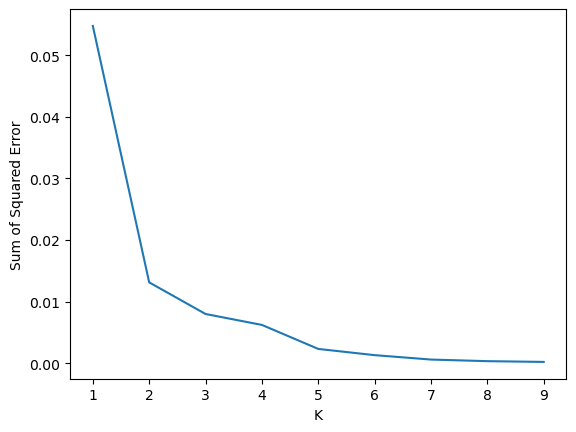

In [48]:
plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(k_rng , sse)
